In [5]:
# Run this once to install dependencies
import sys
!{sys.executable} -m pip install pydicom opencv-python-headless pandas matplotlib seaborn scikit-learn --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pydicom                          # reads DICOM medical image files
import numpy as np                     # numerical operations on image arrays
import pandas as pd                    # reads and manipulates the labels CSV
import matplotlib.pyplot as plt        # plotting images and charts
import seaborn as sns                  # prettier statistical charts
import os                              # file path operations
import cv2                             # image processing (CLAHE later)
from pathlib import Path               # cleaner path handling on Windows

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
# Define paths — adjust BASE_DIR to match your actual project location
BASE_DIR = Path(r"E:\Portfolio-Projects\Pneumonia_Detection")

TRAIN_IMAGES_DIR = BASE_DIR / "data" / "raw" / "stage_2_train_images"
LABELS_CSV       = BASE_DIR / "data" / "raw" / "stage_2_train_labels.csv"

# Verify the paths exist
print(f"Images folder exists : {TRAIN_IMAGES_DIR.exists()}")
print(f"Labels CSV exists    : {LABELS_CSV.exists()}")
print(f"Total DICOM files    : {len(list(TRAIN_IMAGES_DIR.glob('*.dcm')))}")

Images folder exists : True
Labels CSV exists    : True
Total DICOM files    : 26684


Image shape  : (1024, 1024)
Data type    : uint8
Pixel range  : 0 – 245


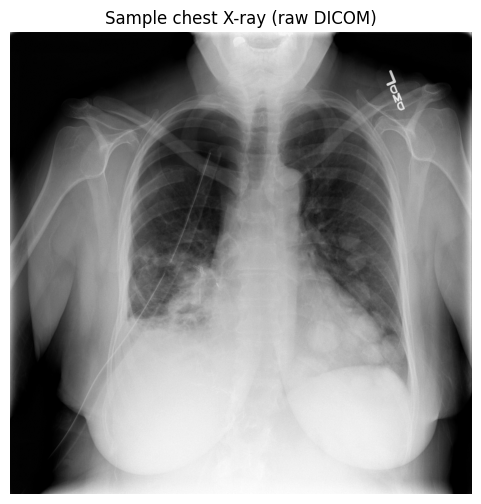

In [8]:
# Grab the path to one DICOM file
sample_dcm_path = list(TRAIN_IMAGES_DIR.glob("*.dcm"))[0]

# Read the DICOM file
dicom_file = pydicom.dcmread(sample_dcm_path)

# Extract the pixel array (this is the actual image data)
pixel_array = dicom_file.pixel_array

# Inspect it
print(f"Image shape  : {pixel_array.shape}")   # should be (H, W) — grayscale
print(f"Data type    : {pixel_array.dtype}")   # usually uint8 or uint16
print(f"Pixel range  : {pixel_array.min()} – {pixel_array.max()}")

# Display it
plt.figure(figsize=(6, 6))
plt.imshow(pixel_array, cmap="gray")           # cmap="gray" because X-rays are grayscale
plt.title("Sample chest X-ray (raw DICOM)")
plt.axis("off")
plt.show()

In [9]:
# Load the labels CSV into a pandas DataFrame
df_raw = pd.read_csv(LABELS_CSV)

# Inspect the raw structure
print("Shape:", df_raw.shape)
print("\nFirst 10 rows:")
df_raw.head(10)

Shape: (30227, 6)

First 10 rows:


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,NaN,NaN,NaN,NaN,0
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1


In [10]:
# Each pneumonia patient appears multiple times (one row per bounding box)
# We only need one label per image, so we group by patientId
# and take the MAX of Target (if any row = 1, the patient has pneumonia)

df = (df_raw.groupby("patientId")["Target"]
            .max()                        # 1 if any bounding box exists, else 0
            .reset_index())

df.columns = ["patientId", "label"]       # rename for clarity

print(f"Total unique patients : {len(df)}")
print(f"Pneumonia (label=1)   : {(df['label'] == 1).sum()}")
print(f"Normal    (label=0)   : {(df['label'] == 0).sum()}")
print(f"\nClass balance ratio   : {(df['label']==1).sum() / (df['label']==0).sum():.2f}")

Total unique patients : 26684
Pneumonia (label=1)   : 6012
Normal    (label=0)   : 20672

Class balance ratio   : 0.29


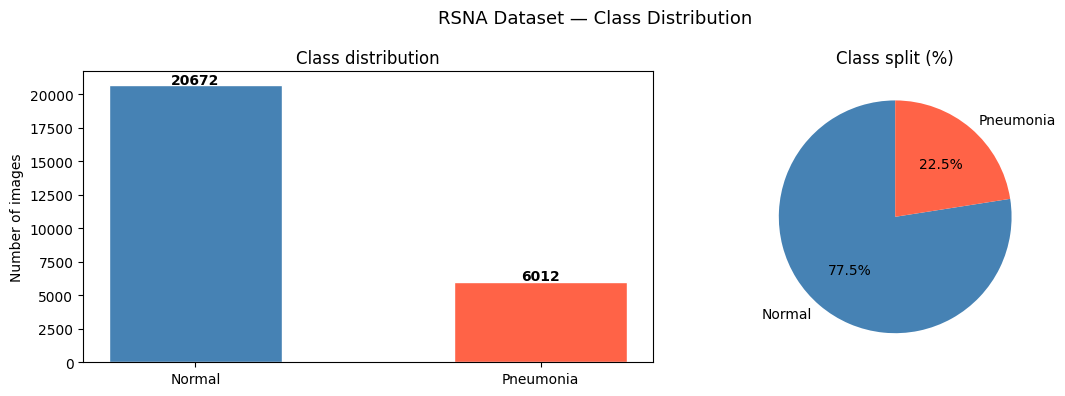

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df["label"].value_counts().sort_index()
axes[0].bar(["Normal", "Pneumonia"],
            counts.values,
            color=["steelblue", "tomato"],
            edgecolor="white",
            width=0.5)
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Number of images")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts.values,
            labels=["Normal", "Pneumonia"],
            colors=["steelblue", "tomato"],
            autopct="%1.1f%%",
            startangle=90)
axes[1].set_title("Class split (%)")

plt.suptitle("RSNA Dataset — Class Distribution", fontsize=13)
plt.tight_layout()
plt.show()

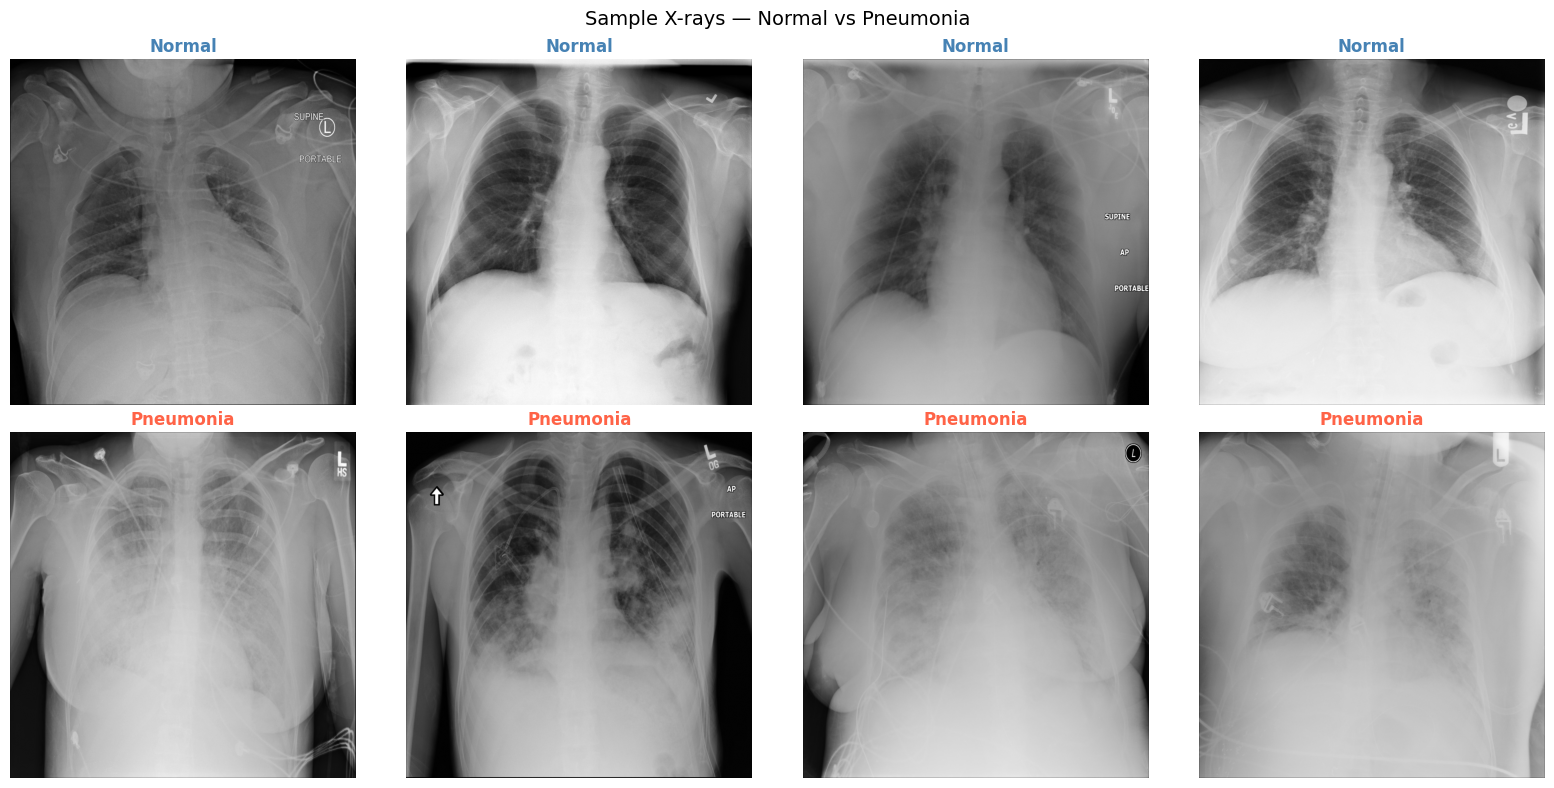

In [12]:
def load_dicom_pixels(patient_id):
    """Load pixel array from a DICOM file given a patient ID."""
    path = TRAIN_IMAGES_DIR / f"{patient_id}.dcm"
    return pydicom.dcmread(path).pixel_array

# Grab 4 normal and 4 pneumonia samples
normal_ids    = df[df["label"] == 0]["patientId"].sample(4, random_state=42).values
pneumonia_ids = df[df["label"] == 1]["patientId"].sample(4, random_state=42).values

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Top row — Normal
for i, pid in enumerate(normal_ids):
    axes[0, i].imshow(load_dicom_pixels(pid), cmap="gray")
    axes[0, i].set_title("Normal", color="steelblue", fontweight="bold")
    axes[0, i].axis("off")

# Bottom row — Pneumonia
for i, pid in enumerate(pneumonia_ids):
    axes[1, i].imshow(load_dicom_pixels(pid), cmap="gray")
    axes[1, i].set_title("Pneumonia", color="tomato", fontweight="bold")
    axes[1, i].axis("off")

plt.suptitle("Sample X-rays — Normal vs Pneumonia", fontsize=14)
plt.tight_layout()
plt.show()

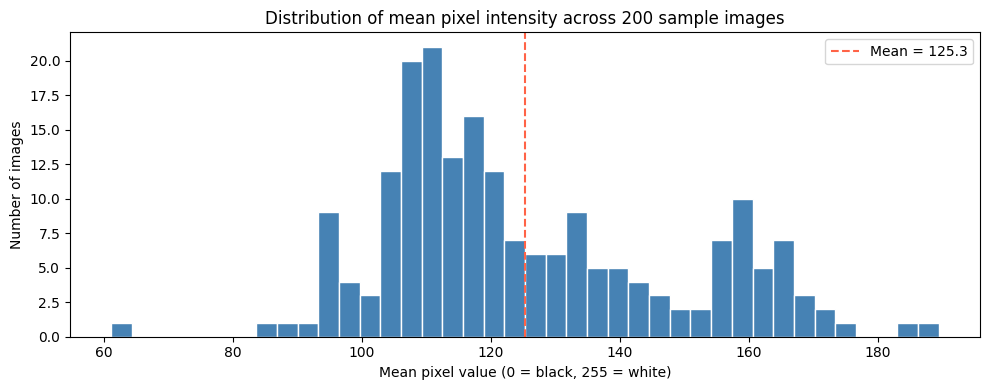

Average mean intensity : 125.3
Std deviation          : 22.7


In [13]:
# Sample 200 images — reading all 26k would take too long locally
sample_ids = df.sample(200, random_state=42)["patientId"].values

mean_intensities = []
for pid in sample_ids:
    pixels = load_dicom_pixels(pid)
    mean_intensities.append(pixels.mean())   # average brightness of each image

plt.figure(figsize=(10, 4))
plt.hist(mean_intensities, bins=40,
         color="steelblue", edgecolor="white")
plt.title("Distribution of mean pixel intensity across 200 sample images")
plt.xlabel("Mean pixel value (0 = black, 255 = white)")
plt.ylabel("Number of images")
plt.axvline(np.mean(mean_intensities),
            color="tomato", linestyle="--",
            label=f"Mean = {np.mean(mean_intensities):.1f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average mean intensity : {np.mean(mean_intensities):.1f}")
print(f"Std deviation          : {np.std(mean_intensities):.1f}")

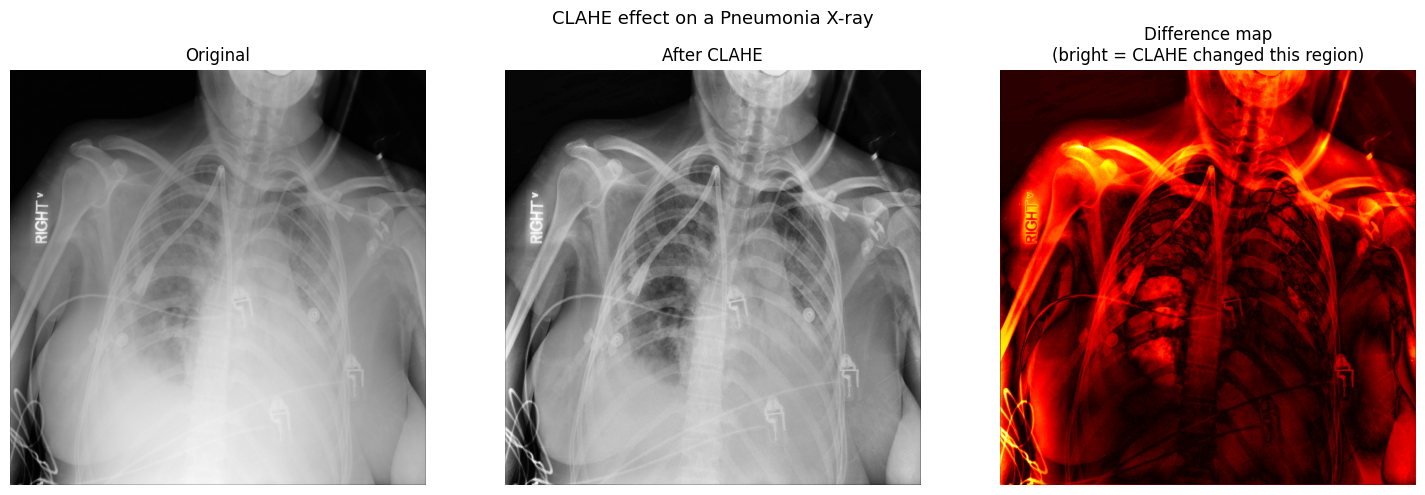

Original  — mean: 109.1,  std: 54.4
After CLAHE — mean: 120.9, std: 55.6


In [14]:
# Pick one pneumonia sample to demonstrate CLAHE on
demo_id     = df[df["label"] == 1]["patientId"].iloc[0]
raw_pixels  = load_dicom_pixels(demo_id)          # original pixel array

# CLAHE works on uint8 images — confirm dtype then apply
# clipLimit  : controls how aggressively contrast is enhanced
#              too high = noisy, too low = no effect. 2.0 is the medical imaging standard
# tileGridSize : divides image into tiles and equalises each one locally
#                (8,8) means 8x8 grid of tiles — standard for chest X-rays

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_pixels = clahe.apply(raw_pixels)          # apply CLAHE

# Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(raw_pixels, cmap="gray")
axes[0].set_title("Original", fontsize=12)
axes[0].axis("off")

axes[1].imshow(enhanced_pixels, cmap="gray")
axes[1].set_title("After CLAHE", fontsize=12)
axes[1].axis("off")

# Difference map — shows exactly what CLAHE changed
diff = cv2.absdiff(raw_pixels, enhanced_pixels)
axes[2].imshow(diff, cmap="hot")                   # hot colormap highlights differences
axes[2].set_title("Difference map\n(bright = CLAHE changed this region)", fontsize=12)
axes[2].axis("off")

plt.suptitle(f"CLAHE effect on a Pneumonia X-ray", fontsize=13)
plt.tight_layout()
plt.show()

# Pixel stats before vs after
print(f"Original  — mean: {raw_pixels.mean():.1f},  std: {raw_pixels.std():.1f}")
print(f"After CLAHE — mean: {enhanced_pixels.mean():.1f}, std: {enhanced_pixels.std():.1f}")

In [15]:
from sklearn.model_selection import train_test_split

# ── Step 1 : separate out test set (10%) ──────────────────────────────────────
df_trainval, df_test = train_test_split(
    df,
    test_size=0.10,          # 10% held out as final test set
    stratify=df["label"],    # preserves 77.5/22.5 ratio in both halves
    random_state=42          # fixed seed — split is reproducible
)

# ── Step 2 : split remaining 90% into train (80%) and val (10%) ───────────────
# 0.111 of 90% ≈ 10% of total
df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.111,
    stratify=df_trainval["label"],
    random_state=42
)

# ── Step 3 : verify sizes and class ratios ────────────────────────────────────
for name, split in [("Train", df_train),
                    ("Val",   df_val),
                    ("Test",  df_test)]:
    total      = len(split)
    pneumonia  = (split["label"] == 1).sum()
    normal     = (split["label"] == 0).sum()
    print(f"{name:5s} → total: {total:5d} | "
          f"Normal: {normal:5d} ({normal/total*100:.1f}%) | "
          f"Pneumonia: {pneumonia:4d} ({pneumonia/total*100:.1f}%)")

print(f"\nTotal accounted for : {len(df_train) + len(df_val) + len(df_test)}")
print(f"Original total      : {len(df)}")

Train → total: 21349 | Normal: 16539 (77.5%) | Pneumonia: 4810 (22.5%)
Val   → total:  2666 | Normal:  2065 (77.5%) | Pneumonia:  601 (22.5%)
Test  → total:  2669 | Normal:  2068 (77.5%) | Pneumonia:  601 (22.5%)

Total accounted for : 26684
Original total      : 26684


In [16]:
# Add a column indicating which split each image belongs to
df_train["split"] = "train"
df_val["split"]   = "val"
df_test["split"]  = "test"

# Combine and save
df_split = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Save to the processed data folder
SPLIT_CSV = BASE_DIR / "data" / "processed" / "dataset_split.csv"
df_split.to_csv(SPLIT_CSV, index=False)

print(f"Split saved to : {SPLIT_CSV}")
print(f"\nPreview:")
df_split.sample(6, random_state=1)

Split saved to : E:\Portfolio-Projects\Pneumonia_Detection\data\processed\dataset_split.csv

Preview:


,patientId,label,split
23399,d0e2c444-b8a0-4bad-a77f-6ca32cce0b10,0,val
22168,c46bdaeb-ee46-4de7-ae4c-32129df7eccb,0,val
15361,62605623-c91f-4c49-8f2a-96421b487090,0,train
10424,73fd2eb6-5d51-4f15-8cf2-4a8159592d2f,0,train
24024,f4cb870f-426d-4caa-ba6e-e8051a4fe66a,0,test
4901,17e95c76-ae2f-4ad9-b713-08b617d3c9bd,1,train


In [ ]:
train_ids = set(df_train["patientId"])
val_ids   = set(df_val["patientId"])
test_ids  = set(df_test["patientId"])

print("Leakage checks:")
print(f"  Train ∩ Val  : {len(train_ids & val_ids)}   ← must be 0")
print(f"  Train ∩ Test : {len(train_ids & test_ids)}   ← must be 0")
print(f"  Val   ∩ Test : {len(val_ids   & test_ids)}   ← must be 0")

if len(train_ids & val_ids) == 0 and \
   len(train_ids & test_ids) == 0 and \
   len(val_ids & test_ids) == 0:
    print("\n  No leakage detected — split is clean ")
else:
    print("\n  WARNING: leakage detected ")

Leakage checks:
  Train ∩ Val  : 0   ← must be 0
  Train ∩ Test : 0   ← must be 0
  Val   ∩ Test : 0   ← must be 0

  No leakage detected — split is clean ✅


In [24]:
import sys
sys.path.append(str(BASE_DIR / "src"))    # so Python can find dataset.py

from dataset import RSNADataset
from torchvision import transforms
from torch.utils.data import DataLoader

# ── Transforms ────────────────────────────────────────────────────────────────
# Training only — augmentations make the model more robust
# These are medical-safe: we never flip vertically (lungs aren't upside down)
# and we keep rotation small (±15°) to avoid distorting anatomy

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),          # lungs are symmetric L/R
    transforms.RandomRotation(degrees=15),            # small rotation only
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2),             # scanner exposure variation
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # ImageNet mean — matches
                         std=[0.229, 0.224, 0.225])  # ConvNeXt/ViT pretraining
])

# Val and test — no augmentation, only normalisation
val_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Load the split CSV ─────────────────────────────────────────────────────────
df_split = pd.read_csv(SPLIT_CSV)

df_train = df_split[df_split["split"] == "train"].reset_index(drop=True)
df_val   = df_split[df_split["split"] == "val"].reset_index(drop=True)
df_test  = df_split[df_split["split"] == "test"].reset_index(drop=True)

# ── Build Datasets ─────────────────────────────────────────────────────────────
train_dataset = RSNADataset(df_train, TRAIN_IMAGES_DIR, transform=train_transform)
val_dataset   = RSNADataset(df_val,   TRAIN_IMAGES_DIR, transform=val_transform)
test_dataset  = RSNADataset(df_test,  TRAIN_IMAGES_DIR, transform=val_transform)

# ── Build DataLoaders ──────────────────────────────────────────────────────────
# batch_size=32 : standard starting point, fits local RAM for testing
# num_workers=0 : set to 0 on Windows to avoid multiprocessing errors
# pin_memory    : speeds up CPU→GPU transfer (set True when using GPU)

train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False, num_workers=0, pin_memory=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 668
Val batches   : 84
Test batches  : 84


In [25]:
# Grab one batch and verify shapes and value ranges
images, labels = next(iter(train_loader))

print(f"Batch image shape : {images.shape}")
# Expected: torch.Size([32, 3, 224, 224])
# meaning  → 32 images, 3 channels, 224×224 pixels

print(f"Batch label shape : {labels.shape}")
# Expected: torch.Size([32])

print(f"Image dtype       : {images.dtype}")
# Expected: torch.float32

print(f"Pixel value range : {images.min():.3f} to {images.max():.3f}")
# Expected: roughly -2.1 to +2.6 after ImageNet normalisation

print(f"Labels in batch   : {labels.tolist()[:10]}...")
# Should show a mix of 0s and 1s

Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])
Image dtype       : torch.float32
Pixel value range : -2.118 to 2.640
Labels in batch   : [1, 1, 1, 0, 0, 0, 1, 0, 0, 0]...


In [ ]:
# Phase 3

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm                          # gives us ConvNeXt-Base pretrained
import pydicom
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             f1_score,
                             recall_score)
from pathlib import Path
import os
import time

# Confirm GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device         : {device}")
print(f"GPU name       : {torch.cuda.get_device_name(0)}")
print(f"VRAM available : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

ModuleNotFoundError: No module named 'timm'